In [1]:
import pynhd as nhd
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings

from __future__ import annotations
from pathlib import Path
import dataretrieval.nwis as nwis
from datetime import datetime
import matplotlib.patches as mpatches
import py3dep
import pygeohydro as gh
import networkx as nx
import xarray as xr
import xrspatial

warnings.filterwarnings("ignore")



ModuleNotFoundError: No module named 'supporting_scripts'

In [2]:
nldi=NLDI()
usgs_gage_id = "09010500" # NWIS id for Colorado River below Baker Gulch
station_id = usgs_gage_id
basinname = 'ColoradoRiverBasin'

## Streamflow Data Acquisition

In [3]:
#get streamflow information using the NWIS id for the gage and ghte get_usgs_streamflow function in getData.py 
streamflow = getData.get_usgs_streamflow(usgs_gage_id)

Retrieving data for Site: 09010500 from 1980-01-01 to 2026-03-31...


In [4]:
streamflow.tail()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2026-03-26 00:00:00+00:00,09010500,-999999.0,"P, Ice"
2026-03-27 00:00:00+00:00,09010500,110.0,P
2026-03-28 00:00:00+00:00,09010500,88.4,P
2026-03-29 00:00:00+00:00,09010500,89.8,P
2026-03-30 00:00:00+00:00,09010500,92.5,P


In [ ]:
cleaned = dataprocessing.clean_nwis_dataframe(streamflow) # uses the clean_nwis_dataframe function located in dataprocessing.py file in supporting_scripts to clean data
#set the index name to Date
cleaned.index.name = "Date"
cleaned.tail()

,site_no,flow_cms
Date,,
2026-03-26,09010500,NaN
2026-03-27,09010500,3.114848
2026-03-28,09010500,2.503205
2026-03-29,09010500,2.542849
2026-03-30,09010500,2.619304


In [6]:
#save the cleaned dataframe to a csv file

OutputFolder = 'files/NWIS'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
cleaned.to_csv(f'{OutputFolder}/streamflow_{usgs_gage_id}.csv')

## SNOTEL Data Acquisition

#### Locate SNOTEL Sites

In [7]:
import importlib
importlib.reload(dataprocessing)

<module 'supporting_scripts.dataprocessing' from '/uufs/chpc.utah.edu/common/home/u1405836/Hydroinformatics/Hydro-Assignment-2/supporting_scripts/dataprocessing.py'>

In [8]:
basinname = 'ColoradoRiverBasin'
#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(station_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{station_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{station_id}", "upstreamMain", "flowlines", distance=9999
)

In [9]:
mapping.basin_mapping(basin, site_feature) #create a map to show where the catchment is

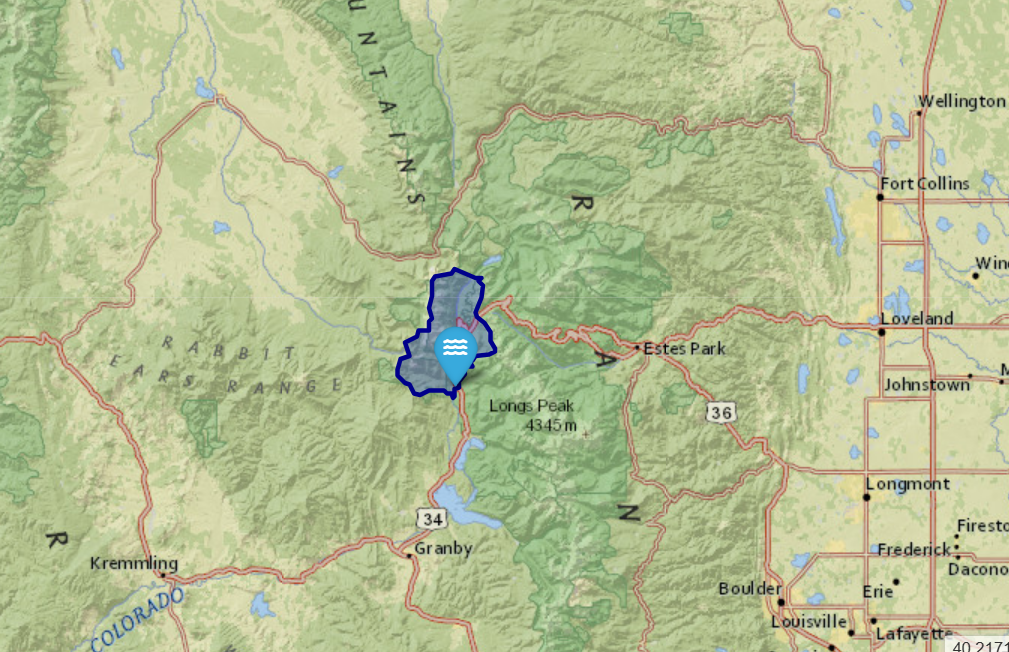

In [10]:
# Identify Snotel Sites within Basin and return their characteristics
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,565_CO_SNTL,Lake Irene,SNOTEL,3261.360107,40.414322,-105.819801,Colorado,140100010302,13TDE,Southern Rocky Mountains,1978-10-01,2026-03-31,True,POINT (-105.8198 40.41432)
1,688_CO_SNTL,Phantom Valley,SNOTEL,2752.343994,40.399368,-105.847572,Colorado,140100010302,13TDE,Southern Rocky Mountains,1979-10-01,2026-03-31,True,POINT (-105.84757 40.39937)


In [ ]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature) #map snotels in watersh0ed

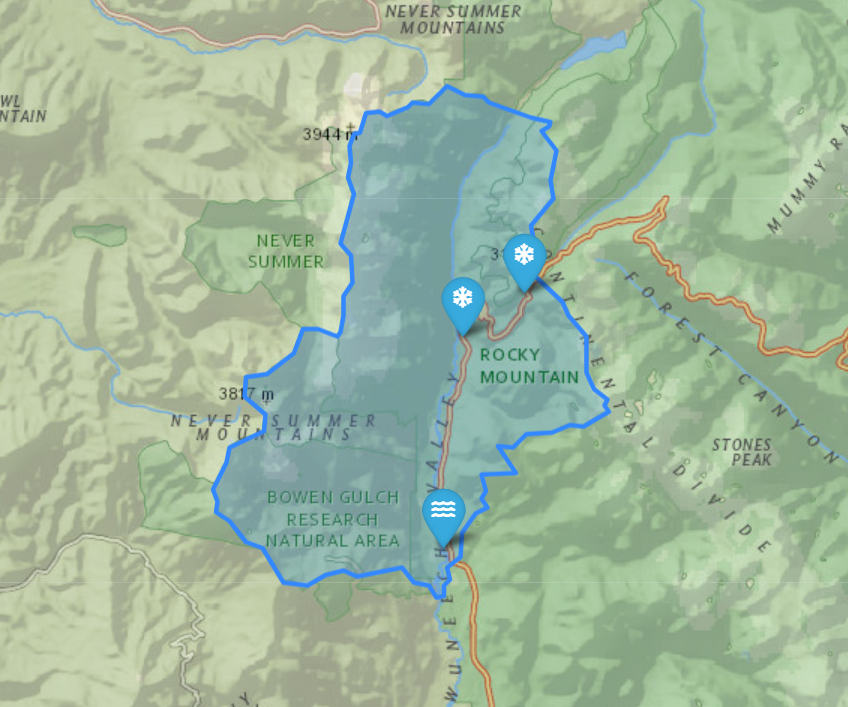

#### Acquire Snotel Data

In [12]:
#Pull SNOTEL/SWE data

# '''
# Data pulled from: Gagliano, E. (2024).
# snotel_ccss_stations (Version v1.0) [Computer software]. https://github.com/egagli/snotel_ccss_stations
# '''

#read Phantom Valley csv into dataframe
snotel_688 = pd.read_csv('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/refs/heads/main/data/688_CO_SNTL.csv')
print("CSV 1 loaded successfully")
#read Lake Irene csv into dataframe
snotel_565 = pd.read_csv('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/refs/heads/main/data/565_CO_SNTL.csv')
print("CSV 2 loaded successfully")

CSV 1 loaded successfully
CSV 2 loaded successfully


In [13]:
#save raw data
import os 

OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

snotel_565.to_csv(f'{OutputFolder}/SNOTEL_565_CO',index=False)
snotel_688.to_csv(f'{OutputFolder}/SNOTEL_688_CO',index=False)

In [14]:
# Process snotel data using processSNOTEL function in dataprocessing.py. this function save data in /files/SNOTEL_processed
sites = list(gdf_in_bbox.code)
stateab = 'CO'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab)

sitedict['565_CO_SNTL'].head()

565_CO_SNTL
['1979_SWE_in', '1980_SWE_in', '1981_SWE_in', '1982_SWE_in', '1983_SWE_in', '1984_SWE_in', '1985_SWE_in', '1986_SWE_in', '1987_SWE_in', '1988_SWE_in', '1989_SWE_in', '1990_SWE_in', '1991_SWE_in', '1992_SWE_in', '1993_SWE_in', '1994_SWE_in', '1995_SWE_in', '1996_SWE_in', '1997_SWE_in', '1998_SWE_in', '1999_SWE_in', '2000_SWE_in', '2001_SWE_in', '2002_SWE_in', '2003_SWE_in', '2004_SWE_in', '2005_SWE_in', '2006_SWE_in', '2007_SWE_in', '2008_SWE_in', '2009_SWE_in', '2010_SWE_in', '2011_SWE_in', '2012_SWE_in', '2013_SWE_in', '2014_SWE_in', '2015_SWE_in', '2016_SWE_in', '2017_SWE_in', '2018_SWE_in', '2019_SWE_in', '2020_SWE_in', '2021_SWE_in', '2022_SWE_in', '2023_SWE_in', '2024_SWE_in', '2025_SWE_in', '2026_SWE_in']
688_CO_SNTL
['1981_SWE_in', '1982_SWE_in', '1983_SWE_in', '1984_SWE_in', '1985_SWE_in', '1986_SWE_in', '1987_SWE_in', '1988_SWE_in', '1989_SWE_in', '1990_SWE_in', '1991_SWE_in', '1992_SWE_in', '1993_SWE_in', '1994_SWE_in', '1995_SWE_in', '1996_SWE_in', '1997_SWE_in',

,M,D,1979_SWE_in,1980_SWE_in,1981_SWE_in,1982_SWE_in,1983_SWE_in,1984_SWE_in,1985_SWE_in,1986_SWE_in,...,2026_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0330,...,0.0000,0.0,0.0,0.0,0.002010,0.0,0.0,0.00228,0.0330,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,...,0.0000,0.0,0.0,0.0,0.002383,0.0,0.0,0.00738,0.0305,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,...,0.0000,0.0,0.0,0.0,0.003017,0.0,0.0,0.00838,0.0533,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0178,...,0.0000,0.0,0.0,0.0,0.003596,0.0,0.0,0.00838,0.0533,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0102,...,0.0025,0.0,0.0,0.0,0.003863,0.0,0.0,0.01170,0.0533,2023-10-05


## Catchment Attributes Acquisition

In [15]:
basin = nldi.get_basins(station_id)
geometry = basin.geometry.iloc[0]

In [16]:
topo = py3dep.get_map(["DEM", "Slope Degrees"], geometry, 90, geo_crs=4326, crs=5070) # Get the DEM and slope for the basin geometry at 90m resolution, reproject to 5070, and convert slope from degrees to m/m
dem = py3dep.get_dem(geometry, 30) # Get the DEM for the basin geometry at 30m resolution
dem = dem.rio.reproject(5070) # Reproject the DEM to match the CRS of the slope and the flowlines
slope = py3dep.deg2mpm(xrspatial.slope(dem)) # Calculate slope in m/m from the DEM using xrspatial, which handles the spatial resolution and units correctly
topo = xr.merge([dem, slope]) # Merge the DEM and slope into a single xarray dataset

In [17]:
#save DEM files
if not os.path.exists('files/DEM'):
    os.makedirs('files/DEM')
dem.rio.to_raster(Path("files/DEM", f"dem_{station_id}.tif"))

In [18]:
# build a dataframe to get record basin information
#get a range of elevation within the basin
ave_basin_elevation = topo.elevation.mean().values
min_basin_elevation = topo.elevation.min().values
max_basin_elevation = topo.elevation.max().values

#get the average slope of the basin
ave_basin_slope = topo.slope.mean().values

#get the basin area
gs = gpd.GeoSeries([geometry], crs="EPSG:4326")

# Project to a metric system (EPSG:3857 is Web Mercator / meters)
gs_meters = gs.to_crs(epsg=3857)

# Calculate area (returns square meters)
area_m2 = gs_meters.area.iloc[0]
area_km2 = area_m2 / 1_000_000

#Put the informatininto  a dataframe
basin_info = pd.DataFrame({
    "Basin_Name": [basinname],
    "station_id": [station_id],
    "Average_Elevation_m": [ave_basin_elevation],
    "Minimum_Elevation_m": [min_basin_elevation],
    "Maximum_Elevation_m": [max_basin_elevation],
    "Average_Slope": [ave_basin_slope],
    "Area_km2": [area_km2],
})

gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[geometry])

# Use this gdf in your nlcd_bygeom call nlcd is the National Land Cover Database, and nlcd_bygeom is a function in pygeohydro that retrieves the land cover types within a given geometry
# nlcd_data = gh.nlcd_bygeom(gdf)

# station_ids = [station_id]
# #geometry = NLDI().get_basins(station_ids)
# basin.index = station_ids

In [19]:
# cover and impervious descriptor data at a 100 m resolution for all three stations
desc = gh.nlcd_bygeom(basin.geometry, 100, years={"descriptor": 2019}, ssl=False)
#land cover data at a 100 m resolution for all three stations for 2016 and 2019
lulc = gh.nlcd_bygeom(basin.geometry, 100, years={"cover": [2016, 2019]}, ssl=False)


In [20]:
stats = gh.cover_statistics(lulc[f"USGS-{station_id}"].cover_2019) # Get the land cover statistics for the 2019 land cover data for the station's basin geometry
roughness = gh.overland_roughness(lulc[f"USGS-{station_id}"].cover_2019) # Get the overland flow roughness for the 2019 land cover data for the station's basin geometry

In [21]:
cmap, norm, levels = gh.plot.cover_legends() # Get the colormap, normalization, and levels for plotting land cover data using pygeohydro's built-in legends
cover = lulc[f"USGS-{station_id}"].cover_2019 # Get the 2019 land cover data for the station's basin geometry
unique_lulc = np.unique(cover.values) # Get the unique land cover codes present in the cover data for the station's basin geometry

nlcd_legend = {
    11: "Open Water",
    12: "Perennial Ice/Snow",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land (Rock/Sand/Clay)",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
    127: "No Data / Masked"  # Often used as a fill or background value
}

# To translate your list of unique values:
unique_names = [nlcd_legend.get(code, "Unknown") for code in unique_lulc]


unique_names


['Open Water',
 'Perennial Ice/Snow',
 'Developed, Open Space',
 'Developed, Low Intensity',
 'Developed, Medium Intensity',
 'Developed, High Intensity',
 'Barren Land (Rock/Sand/Clay)',
 'Deciduous Forest',
 'Evergreen Forest',
 'Shrub/Scrub',
 'Grassland/Herbaceous',
 'Woody Wetlands',
 'Emergent Herbaceous Wetlands',
 'No Data / Masked']

In [22]:
#Create a vectorized version of your dictionary mapping
def map_names(val):
    return nlcd_legend.get(val, "Unknown")

# Create a vectorized function that can be applied to the entire array of land cover codes to get the corresponding names
v_map_names = np.vectorize(map_names) 

# Create a new DataArray with the string names
cover_names = xr.apply_ufunc(v_map_names, cover)

# Get unique values and their pixel counts
vals, counts = np.unique(cover.values, return_counts=True)

# Build a summary DataFrame
summary = pd.DataFrame({
    "code": vals,
    "count": counts,
    "name": [nlcd_legend.get(v, "Unknown") for v in vals]
})

# Calculate percentage (ignoring 127/No Data in the total pixel count)
total_pixels = summary[summary['code'] != 127]['count'].sum()
summary['percent'] = (summary['count'] / total_pixels) * 100
summary = summary[summary['code'] != 127]

#print(summary.sort_values("percent", ascending=False))

# copy the summary dataframe to a new variable to transpose
lulc = summary.copy()
#remove the following columns from the dataframe: count, code
lulc = lulc.drop(columns=["count", "code"])
#set the name column as the index of the dataframe
lulc.rename(columns={"name": "Basin_Name", 'percent': basin_info['Basin_Name'].values[0]}, inplace=True)
lulc.set_index("Basin_Name", inplace=True)
#transpose the dataframe
lulc = lulc.T
lulc.columns = lulc.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("/", "_")

# #combine the basin info dataframe with the lulc dataframe
basin_info.set_index('Basin_Name', inplace=True)
basin_info = pd.concat([basin_info, lulc], axis=1)

OutputFolder = 'files/basin_info'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
basin_info.to_csv(f'{OutputFolder}/basin_info_{station_id}.csv')

basin_info


,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,Area_km2,Open_Water,Perennial_Ice_Snow,"Developed,_Open_Space","Developed,_Low_Intensity","Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
ColoradoRiverBasin,09010500,3200.7634,2659.6445,3941.0696,0.363304,292.895387,0.076363,3.148496,0.516917,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372


## Data Processing

#### SNOTEL Data Processing

In [23]:
unprocessed_SNOTEL = {}
path = 'files/SNOTEL'

for filename in os.listdir(path):
    if filename.endswith('.csv'):
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        
        unprocessed_SNOTEL[name]['datetime'] = pd.to_datetime(unprocessed_SNOTEL[name]['datetime'])
        unprocessed_SNOTEL[name].set_index('datetime', inplace=True)
        
        unprocessed_SNOTEL[name].rename(columns={'WTEQ': f"{name}_SWE_cm"}, inplace=True)
        unprocessed_SNOTEL[name][f"{name}_SWE_cm"] = unprocessed_SNOTEL[name][f"{name}_SWE_cm"] * 2.54
        
        # Keep only the SWE column
        unprocessed_SNOTEL[name] = unprocessed_SNOTEL[name][[f"{name}_SWE_cm"]]
        
        print(f"{name}: {len(unprocessed_SNOTEL[name])} start date: {unprocessed_SNOTEL[name].index.min()} end date: {unprocessed_SNOTEL[name].index.max()}")

565: 17347 start date: 1978-10-01 00:00:00 end date: 2026-03-29 00:00:00
688: 16616 start date: 1980-10-01 00:00:00 end date: 2026-03-29 00:00:00


In [24]:
#The site with the latest start date will guide the rest
latest_start_date = max([df.index.min() for df in unprocessed_SNOTEL.values()])

#The site with the earliest end date will guide the rest
soonest_end_date = min([df.index.max() for df in unprocessed_SNOTEL.values()])
for key in unprocessed_SNOTEL.keys():
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index >= latest_start_date]
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index <= soonest_end_date]

#merge all dictionary dataframes into one larger dataframe
SNOTEL_df = pd.concat(unprocessed_SNOTEL.values(), axis=1)
#set the date index to be the index of the first dataframe in the dictionary

SNOTEL_df.tail()

,565_SWE_cm,688_SWE_cm
datetime,,
2026-03-25,0.774192,NaN
2026-03-26,0.728980,0.161290
2026-03-27,0.709676,0.122682
2026-03-28,0.690372,0.077470
2026-03-29,0.677418,0.045212


#### Streamflow Data Processing

In [25]:
#load the streamflow data
streamflow_df = pd.read_csv(f"files/NWIS/streamflow_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
streamflow_df['Date'] = pd.to_datetime(streamflow_df['Date'])
streamflow_df.set_index('Date', inplace=True)

streamflow_df.head()

,site_no,flow_cms
Date,,
1980-01-01,9010500,0.226534
1980-01-02,9010500,0.226534
1980-01-03,9010500,0.226534
1980-01-04,9010500,0.226534
1980-01-05,9010500,0.226534


In [26]:
#load catchment info
basin_info = pd.read_csv(f"files/basin_info/basin_info_{station_id}.csv")
basin_info.head()

,Unnamed: 0,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,Area_km2,Open_Water,Perennial_Ice_Snow,"Developed,_Open_Space","Developed,_Low_Intensity","Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,292.895387,0.076363,3.148496,0.516917,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372


#### Merge Data into One DataFrame

In [27]:
#find the latest start date and the earliest end date for SNOTEL_df cleaned
begin_date = max([df.index.min() for df in [SNOTEL_df,  streamflow_df]]) 
end_date = min([df.index.max() for df in [SNOTEL_df,  streamflow_df]]) 

#clip each dataframe to have the same begin and end dates
SNOTEL_df = SNOTEL_df[(SNOTEL_df.index >= begin_date) & (SNOTEL_df.index <= end_date)]

streamflow_df = streamflow_df[(streamflow_df.index >= begin_date) & (streamflow_df.index <= end_date)]

In [28]:
#merge the SNOTEL_df and streamflow dataframes
Hydro_df = pd.concat([SNOTEL_df, streamflow_df], axis=1)
#put the site_no column, second to last, and streamfow column, last column, as the first two columns in the dataframe
cols = Hydro_df.columns.tolist()
cols = cols[-2:] + cols[:-2]
Hydro_df = Hydro_df[cols]


In [29]:
#all of the NaN values here should be 0, fill them
Hydro_df = Hydro_df.fillna(0)
Hydro_df.head()

,site_no,flow_cms,565_SWE_cm,688_SWE_cm
1980-10-01,9010500,0.453069,0.0,0.0
1980-10-02,9010500,0.396435,0.0,0.0
1980-10-03,9010500,0.368118,0.0,0.0
1980-10-04,9010500,0.368118,0.0,0.0
1980-10-05,9010500,0.368118,0.0,0.0


In [30]:
#add in the basin info as columns in the dataframe, repeat the values for each row
for col in basin_info.columns:
    Hydro_df[col] = basin_info[col][0]

Hydro_df.head()

,site_no,flow_cms,565_SWE_cm,688_SWE_cm,Unnamed: 0,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,...,"Developed,_Low_Intensity","Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
1980-10-01,9010500,0.453069,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-02,9010500,0.396435,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-03,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-04,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372
1980-10-05,9010500,0.368118,0.0,0.0,ColoradoRiverBasin,9010500,3200.7634,2659.6445,3941.0696,0.363304,...,0.076363,0.023496,0.017622,3.724154,0.105733,59.821429,18.708882,9.151786,2.267387,2.361372


In [31]:
#save final DataFrame
import os 

OutputFolder = 'files/Hydro_Df'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

Hydro_df.to_csv(f'{OutputFolder}/Hydro_Df',index=True)
